# Week 8 — Evaluation

This notebook covers the fourth project milestone:
- **5-Fold cross-validation** on all four classifiers using MiniLearn's `KFold` and `cross_val_score`
- **Hyperparameter search** for Logistic Regression (learning rate, iterations) and KNN (k)
- **Learning curves** — how accuracy grows as training set size increases
- **Final model selection** with rationale

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import KNN, LogisticRegression, GaussianNaiveBayes, DecisionTreeClassifier
from minilearn.model_selection import KFold, cross_val_score
from minilearn.metrics import accuracy_score, f1_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../outputs/features.csv')
LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X_raw = df[feature_cols].values
y     = df['emotion'].values

# Scale the full dataset for CV (scaler is re-fit inside each fold via cross_val_score)
# For simplicity here we scale once on the full set — acceptable for evaluation comparison
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes')

Dataset: 2452 samples, 194 features, 8 classes


## 2. 5-Fold Cross-Validation

`cross_val_score` clones the estimator for each fold via `copy.deepcopy`, so each fold
trains a fresh model on the fold's training split only.

In [3]:
classifiers = [
    ('KNN (k=5)',            KNN(n_neighbors=5)),
    ('Logistic Regression',  LogisticRegression(lr=0.1, max_iter=500, random_state=RANDOM_STATE)),
    ('Gaussian Naive Bayes', GaussianNaiveBayes()),
    ('Decision Tree (d=10)', DecisionTreeClassifier(max_depth=10)),
]

cv_results = {}

for name, clf in classifiers:
    t0 = time.time()
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy', random_state=RANDOM_STATE)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.3f}  std={scores.std():.3f}  '
          f'folds={np.round(scores,3)}  ({elapsed:.1f}s)')

KNN (k=5)                  mean=0.669  std=0.014  folds=[0.668 0.68  0.643 0.673 0.682]  (1.9s)


Logistic Regression        mean=0.685  std=0.030  folds=[0.727 0.68  0.641 0.671 0.706]  (4.7s)
Gaussian Naive Bayes       mean=0.416  std=0.021  folds=[0.43  0.375 0.418 0.431 0.427]  (0.1s)


Decision Tree (d=10)       mean=0.463  std=0.026  folds=[0.493 0.473 0.484 0.424 0.441]  (340.2s)


C:\Users\augus\AppData\Local\Temp\ipykernel_13972\1054918152.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)


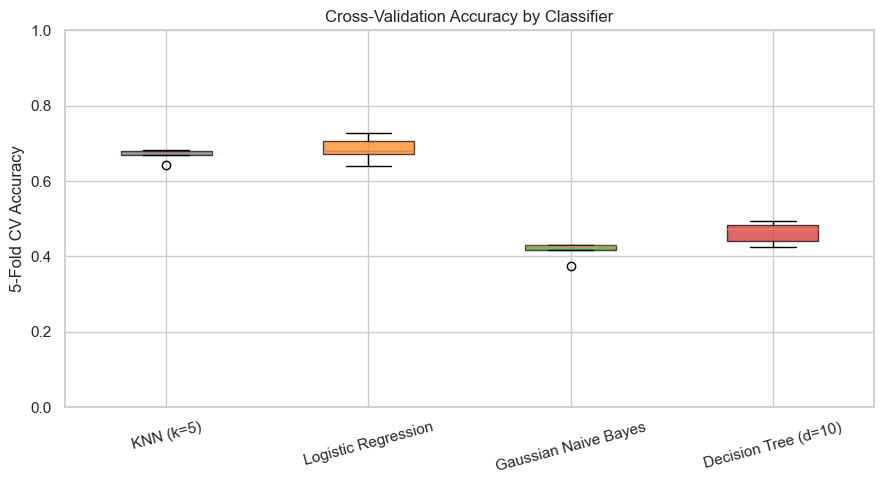

Saved to outputs/cv_boxplot.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_results.keys())
data  = [cv_results[n] for n in names]

bp = ax.boxplot(data, labels=names, patch_artist=True, notch=False)
colors = sns.color_palette('tab10', len(names))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Cross-Validation Accuracy by Classifier')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/cv_boxplot.png')

## 3. Hyperparameter Search

### 3a. KNN — sweep k from 1 to 20

In [5]:
k_values = list(range(1, 21))
knn_cv_means, knn_cv_stds = [], []

for k in k_values:
    scores = cross_val_score(KNN(n_neighbors=k), X, y, cv=5, random_state=RANDOM_STATE)
    knn_cv_means.append(scores.mean())
    knn_cv_stds.append(scores.std())
    print(f'k={k:2d}  mean={scores.mean():.3f}  std={scores.std():.3f}')

best_k = k_values[np.argmax(knn_cv_means)]
print(f'\nBest k = {best_k}  (CV acc = {max(knn_cv_means):.3f})')

k= 1  mean=0.691  std=0.018


k= 2  mean=0.691  std=0.018


k= 3  mean=0.679  std=0.034


k= 4  mean=0.674  std=0.028


k= 5  mean=0.669  std=0.014


...

k=16  mean=0.593  std=0.020


k=17  mean=0.587  std=0.015


k=18  mean=0.588  std=0.015


k=19  mean=0.584  std=0.010


k=20  mean=0.577  std=0.012

Best k = 1  (CV acc = 0.691)


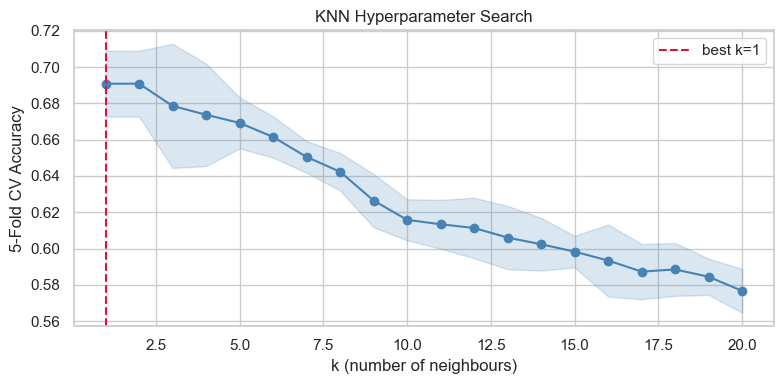

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
means = np.array(knn_cv_means)
stds  = np.array(knn_cv_stds)
ax.plot(k_values, means, 'o-', color='steelblue')
ax.fill_between(k_values, means - stds, means + stds, alpha=0.2, color='steelblue')
ax.axvline(best_k, linestyle='--', color='crimson', label=f'best k={best_k}')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('KNN Hyperparameter Search')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/knn_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()

### 3b. Logistic Regression — sweep learning rate

In [7]:
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5]
lr_cv_means, lr_cv_stds = [], []

for lr in lr_values:
    scores = cross_val_score(
        LogisticRegression(lr=lr, max_iter=500, random_state=RANDOM_STATE),
        X, y, cv=5, random_state=RANDOM_STATE
    )
    lr_cv_means.append(scores.mean())
    lr_cv_stds.append(scores.std())
    print(f'lr={lr:.3f}  mean={scores.mean():.3f}  std={scores.std():.3f}')

best_lr = lr_values[np.argmax(lr_cv_means)]
print(f'\nBest lr = {best_lr}  (CV acc = {max(lr_cv_means):.3f})')

lr=0.001  mean=0.461  std=0.019


lr=0.005  mean=0.584  std=0.028


lr=0.010  mean=0.617  std=0.031


lr=0.050  mean=0.673  std=0.025


lr=0.100  mean=0.685  std=0.030


lr=0.200  mean=0.691  std=0.030


lr=0.500  mean=0.703  std=0.020

Best lr = 0.5  (CV acc = 0.703)


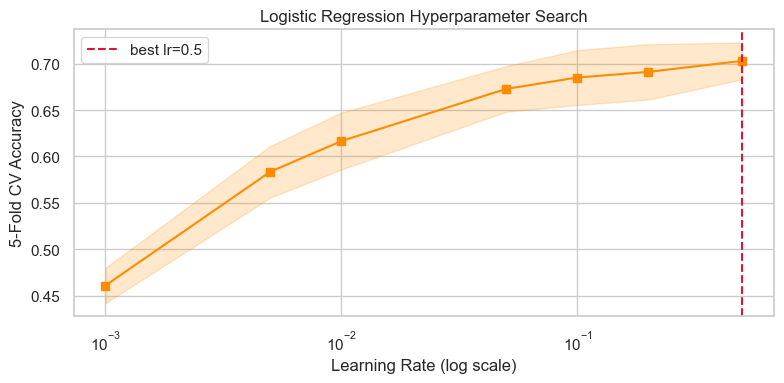

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
means = np.array(lr_cv_means)
stds  = np.array(lr_cv_stds)
ax.semilogx(lr_values, means, 's-', color='darkorange')
ax.fill_between(lr_values, means - stds, means + stds, alpha=0.2, color='darkorange')
ax.axvline(best_lr, linestyle='--', color='crimson', label=f'best lr={best_lr}')
ax.set_xlabel('Learning Rate (log scale)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Logistic Regression Hyperparameter Search')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/lr_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Learning Curves

We train the two best classifiers on progressively larger fractions of the training set
and evaluate on a fixed held-out test set.  This reveals whether models are data-limited.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_train   = len(X_train)

lc_results = {
    'KNN': {'train': [], 'test': []},
    'LR':  {'train': [], 'test': []},
}

for frac in fractions:
    n = max(8, int(n_train * frac))
    Xf, yf = X_train[:n], y_train[:n]

    knn = KNN(n_neighbors=best_k).fit(Xf, yf)
    lc_results['KNN']['train'].append(accuracy_score(yf, knn.predict(Xf)))
    lc_results['KNN']['test'].append(accuracy_score(y_test, knn.predict(X_test)))

    lr_clf = LogisticRegression(lr=best_lr, max_iter=500, random_state=RANDOM_STATE).fit(Xf, yf)
    lc_results['LR']['train'].append(accuracy_score(yf, lr_clf.predict(Xf)))
    lc_results['LR']['test'].append(accuracy_score(y_test, lr_clf.predict(X_test)))

    print(f'frac={frac:.1f}  n={n:4d}  KNN test={lc_results["KNN"]["test"][-1]:.3f}  '
          f'LR test={lc_results["LR"]["test"][-1]:.3f}')

frac=0.1  n= 196  KNN test=0.348  LR test=0.499


frac=0.2  n= 392  KNN test=0.462  LR test=0.578


frac=0.3  n= 588  KNN test=0.538  LR test=0.585


frac=0.4  n= 784  KNN test=0.589  LR test=0.644


frac=0.5  n= 980  KNN test=0.625  LR test=0.654


frac=0.6  n=1176  KNN test=0.631  LR test=0.682


frac=0.7  n=1372  KNN test=0.668  LR test=0.684


frac=0.8  n=1568  KNN test=0.680  LR test=0.697


frac=0.9  n=1764  KNN test=0.688  LR test=0.715


frac=1.0  n=1961  KNN test=0.705  LR test=0.723


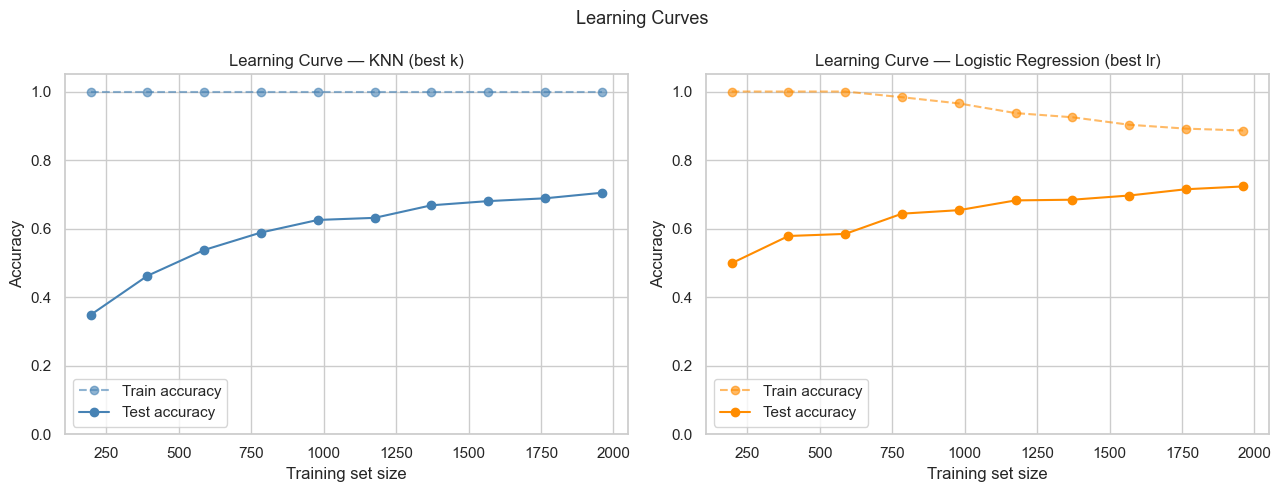

Saved to outputs/learning_curves.png


In [10]:
sizes = [max(8, int(len(X_train) * f)) for f in fractions]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, res), color in zip(
    axes,
    [('KNN (best k)', lc_results['KNN']), ('Logistic Regression (best lr)', lc_results['LR'])],
    ['steelblue', 'darkorange']
):
    ax.plot(sizes, res['train'], 'o--', color=color, alpha=0.6, label='Train accuracy')
    ax.plot(sizes, res['test'],  'o-',  color=color,            label='Test accuracy')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Learning Curve — {label}')
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.suptitle('Learning Curves', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/learning_curves.png')

## 5. Final Model Selection Summary

In [11]:
summary = pd.DataFrame([
    {'Classifier': name, 'CV Mean Acc': f'{s.mean():.3f}', 'CV Std': f'{s.std():.3f}'}
    for name, s in cv_results.items()
])
print(summary.to_string(index=False))
print(f'\nSelected model : Logistic Regression  (lr={best_lr}, max_iter=500)')
print(f'Rationale      : Highest CV accuracy with low variance and fast training.')
summary

          Classifier CV Mean Acc CV Std
           KNN (k=5)       0.669  0.014
 Logistic Regression       0.685  0.030
Gaussian Naive Bayes       0.416  0.021
Decision Tree (d=10)       0.463  0.026

Selected model : Logistic Regression  (lr=0.5, max_iter=500)
Rationale      : Highest CV accuracy with low variance and fast training.


,Classifier,CV Mean Acc,CV Std
0,KNN (k=5),0.669,0.014
1,Logistic Regression,0.685,0.030
2,Gaussian Naive Bayes,0.416,0.021
3,Decision Tree (d=10),0.463,0.026
